# Vanguardis kogudes oleksime ligi viie miljardi võrra rikkamad

**Pikk versioon andmenohikule.** Uuendab 2019. aasta blogipostituse [„Miks John C. Bogle meie pankade fondijuhtide jutu peale muigaks?"](https://tuleva.ee/analuusid/bogle-pensionifondid/) arvutust: mis oleks Eesti inimeste II samba rahast saanud, kui see oleks algusest peale olnud Vanguardi indeksfondides?

Kokkuvõte (seis 31.07.2026):

| | Eesti II samba fondid | Vanguardi portfell 75/25 |
|---|---|---|
| Sissemaksed fondidesse 2003–07/2026 | 7,3 mld € | samad |
| Fondidest välja läinud | 3,4 mld € | samad (eurodes) |
| Vara fondides 31.07.2026 | 7,7 mld € | 12,4 mld € |
| Kasum | 3,7 mld € | 8,4 mld € |
| Rahavoogudega kaalutud tootlus | 5,4% aastas | 9,1% aastas |
| **Vahe** | | **4,7 mld €** ehk üle 9000 € praeguse koguja kohta |

Kõik numbrid allpool arvutatakse `data/` kaustas olevatest failidest uuesti; tekstis olevad arvud on kopeeritud lahtrite väljunditest.

## Andmed ja allikad

- `data/ii_pillar_monthly.csv` – Pensionikeskuse avalikud andmed, kuu lõpu seisuga (tõmbab `_fetch_data.py`):
  - `fund_assets_eur` – kõigi II samba fondide kogumaht („Kogumispensioni fondide maht", kõik fondid);
  - `contributions_funds_eur` – fondidesse laekunud sissemaksed kuus („II samba sissemaksete ülevaade", tüüp F). Enne 2011 annab Pensionikeskuse teenus summad kroonides, need on teisendatud kursiga 15,6466;
  - `contributions_pik_eur` – pensioni investeerimiskontole laekunud raha (tüüp P; ei ole fondides, jäetakse arvutusest välja, kokku ~48 M€);
  - `epi_ii` – II samba üldindeks EPI-II („EPI graafikud"), kõigi II samba fondide mahuga kaalutud tootlus.
- `data/vanguard_annual_returns.csv` – Vanguard Global Stock Index Fund (EUR, MSCI World) ja Vanguard Euro Government Bond Index Fund (EUR) kalendriaasta netotootlused. 2016–2025 ja 2026 YTD (31.07.2026) Vanguardi faktilehtedelt; 2009–2015 Tõnu 2019. aasta arvutustabelist (Vanguardi andmed); 2003–2008 Yahoo Finance'i ajaloost (Institutional EUR klass). Kahe viimase allika kaal tulemuses on väike, sest fondide maht oli siis alla 1 mld.
- Kogujate arv (501 757 = 303 039 aktiivselt juhitud fondides + 198 718 indeksfondides, 31.07.2026) ja indeksfondide maht (2 656 M€ ehk 34,7% II samba varast, 31.07.2026) – Pensionikeskuse andmed Indrek Seppo turuülevaatest. Sama kuupäev kui arvutuse lõppseis.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

DATA = Path('data'); CHARTS = Path('charts'); CHARTS.mkdir(exist_ok=True)
m = pd.read_csv(DATA / 'ii_pillar_monthly.csv', index_col='month')
v = pd.read_csv(DATA / 'vanguard_annual_returns.csv', index_col='year')
m['contributions_funds_eur'] = m['contributions_funds_eur'].fillna(0.0)
print(m.shape, m.index.min(), m.index.max())
m.tail(3)

(290, 5) 2002-07 2026-08


,fund_assets_eur,contributions_funds_eur,contributions_pik_eur,epi_ii,epi_ii_date
month,,,,,
2026-06,7.687952e+09,51522470.89,1075716.80,316.416621,2026-06-30
2026-07,7.658502e+09,53721197.72,1096695.64,311.701709,2026-07-31
2026-08,7.920753e+09,0.00,NaN,320.815290,2026-08-27


In [2]:
v[['global_stock_index_eur_pct', 'euro_govt_bond_index_eur_pct', 'note']]

,global_stock_index_eur_pct,euro_govt_bond_index_eur_pct,note
year,,,
2003,10.64,3.86,NaN
2004,6.10,7.54,NaN
2005,25.87,5.03,NaN
2006,7.14,-0.52,NaN
2007,-1.89,1.77,NaN
2008,-37.76,8.81,NaN
2009,25.48,4.28,NaN
2010,19.14,1.31,NaN
2011,-2.63,3.34,NaN


## Metoodika

Tõnu 2019. aasta loogika: samad rahavood Eesti pensionifondidesse ja Vanguardi indeksfondidesse, võrdleme kasumit. Kaks täiendust:

1. **Väljamaksed.** 2019. aastal võis neid ignoreerida, täna mitte (2021. aasta reform viis fondidest välja ~1,4 mld). Fondidest välja läinud raha tuletame iga kuu kohta mahu, sissemaksete ja EPI-II tootluse abil. Kui kuu netovoog $N$ eeldatakse kuu keskele, siis

   $A_t = A_{t-1}(1+r_t) + N_t(1+r_t/2)  \Rightarrow  N_t = \frac{A_t - A_{t-1}(1+r_t)}{1+r_t/2}, \qquad W_t = C_t - N_t$

   kus $A$ on fondide maht, $r$ EPI-II kuutootlus, $C$ sissemaksed ja $W$ fondidest välja läinud raha (reformi väljamaksed, pensioniea väljamaksed, kindlustuslepingutesse ja PIK-i viidud raha).

2. **Liitkasvatamine.** Alternatiivportfell saab samad netovood ($N_t$ eurodes) ja kasvab Vanguardi fondide tootlusega: 2003–2009 suhtes 50% aktsiad / 50% võlakirjad, alates 2010 75/25 (jäljendab Eesti seaduse toonast aktsiate osakaalu piirangut). Aastatootlus jaotatakse kuudele ühtlaselt; 2026 = jaanuar–juuli. 2019. aasta arvutus rakendas Vanguardi tootlust Eesti fondide tegelikule mahule, st ei liitkasvatanud alternatiivportfelli enda tulu. Uus mudel liitkasvatab, sellepärast on vahe suurem kui vana metoodikaga.

Kasum = vara lõpus − sissemaksed + väljamaksed. Rahavoogudega kaalutud tootlus (IRR) arvutatakse kuuvoogudest.

In [3]:
def run(weights, end='2026-07', start='2003-01', months_2026=7):
    """weights(year) -> aktsiate osakaal. Tagastab (kokkuvõte, aastatabel, kuutabel)."""
    idx = [k for k in m.index if start <= k <= end]
    prev = m.index[m.index.get_loc(idx[0]) - 1]
    a = ap = A0 = m.loc[prev, 'fund_assets_eur']
    rows = []
    for k in idx:
        y = int(k[:4])
        r = m.loc[k, 'epi_ii'] / m.loc[prev, 'epi_ii'] - 1
        c = m.loc[k, 'contributions_funds_eur']
        A = m.loc[k, 'fund_assets_eur']
        N = (A - a * (1 + r)) / (1 + r / 2)
        W = c - N
        w = weights(y)
        Ry = (w * v.loc[y, 'global_stock_index_eur_pct'] + (1 - w) * v.loc[y, 'euro_govt_bond_index_eur_pct']) / 100
        rp = (1 + Ry) ** (1 / (12 if y < 2026 else months_2026)) - 1
        ap_new = ap * (1 + rp) + N * (1 + rp / 2)
        rows.append(dict(month=k, year=y, epi_r=r, C=c, W=W, N=N, P=A - a - N, A=A, Rp=Ry, Pp=ap_new - ap - N, Ap=ap_new))
        a, ap, prev = A, ap_new, k
    mt = pd.DataFrame(rows).set_index('month')
    sumC = A0 + mt.C.sum(); sumW = mt.W.sum()
    yt = mt.groupby('year').agg(sissemaksed=('C', 'sum'), valjamaksed=('W', 'sum'), netovoog=('N', 'sum'),
                                kasum=('P', 'sum'), vanguard_kasum=('Pp', 'sum'), maht_lopp=('A', 'last'),
                                vanguard_maht_lopp=('Ap', 'last'), vanguard_tootlus=('Rp', 'last'))
    epi_ye = m.epi_ii.reindex([f'{y}-12' for y in range(2002, 2026)] + ['2026-07'])
    yt['epi_tootlus'] = [epi_ye.iloc[i + 1] / epi_ye.iloc[i] - 1 for i in range(len(yt))]
    def irr(final):
        flows = [-A0] + list(-mt.N)
        def npv(rm): return sum(f / (1 + rm) ** i for i, f in enumerate(flows)) + final / (1 + rm) ** (len(flows) - 1)
        lo, hi = -0.05, 0.05
        for _ in range(200):
            mid = (lo + hi) / 2
            lo, hi = (mid, hi) if npv(mid) > 0 else (lo, mid)
        return (1 + mid) ** 12 - 1
    s = dict(sissemaksed=sumC, valjamaksed=sumW, vara=a, vanguard_vara=ap, kasum=a - sumC + sumW,
             vanguard_kasum=ap - sumC + sumW, vahe=ap - a, irr=irr(a), vanguard_irr=irr(ap))
    return s, yt, mt

def show(s):
    for k, val in s.items():
        print(f'{k:16s} {val*100:6.2f} %' if 'irr' in k else f'{k:16s} {val/1e9:6.2f} mld €')

base_w = lambda y: 0.5 if y <= 2009 else 0.75
base, years, monthly = run(base_w)
show(base)

sissemaksed        7.31 mld €
valjamaksed        3.36 mld €
vara               7.66 mld €
vanguard_vara     12.40 mld €
kasum              3.70 mld €
vanguard_kasum     8.45 mld €
vahe               4.74 mld €
irr                5.41 %
vanguard_irr       9.12 %


## Aastate lõikes

Sissemaksed, tuletatud väljamaksed, netovoog, EPI-II tootlus ja kasum Eesti fondides; Vanguardi portfelli tootlus ja kasum samadelt voogudelt (miljonites eurodes).

In [4]:
t = years.copy()
for c in ['sissemaksed', 'valjamaksed', 'netovoog', 'kasum', 'vanguard_kasum', 'maht_lopp', 'vanguard_maht_lopp']:
    t[c] = (t[c] / 1e6).round(0).astype(int)
t['epi_tootlus'] = (t['epi_tootlus'] * 100).round(1)
t['vanguard_tootlus'] = (t['vanguard_tootlus'] * 100).round(1)
t = t[['sissemaksed', 'valjamaksed', 'netovoog', 'epi_tootlus', 'kasum', 'vanguard_tootlus', 'vanguard_kasum', 'maht_lopp', 'vanguard_maht_lopp']]
t.to_csv(DATA / 'yearly_table.csv')
t

,sissemaksed,valjamaksed,netovoog,epi_tootlus,kasum,vanguard_tootlus,vanguard_kasum,maht_lopp,vanguard_maht_lopp
year,,,,,,,,,
2003,51,1,50,7.6,3,7.2,2,64,63
2004,84,0,85,9.9,11,6.8,7,159,155
2005,113,2,111,13.1,28,15.4,32,297,298
2006,148,0,148,7.2,30,3.3,12,475,458
2007,195,1,194,6.2,33,-0.1,0,702,652
2008,236,1,235,-24.3,-211,-14.5,-112,727,775
2009,117,7,109,12.7,107,14.9,128,942,1012
2010,37,8,29,9.7,93,14.7,151,1064,1191
2011,122,5,117,-4.5,-51,-1.1,-14,1130,1294


## Kontrollid

Tuletatud väljamaksed peavad klappima teadaolevaga: 2021. aasta septembris maksti reformi esimeses voorus välja ~1,3–1,34 mld (brutona), jaanuaris 2022 94,6 M€ (netona), tavalistel aastatel enne reformi on väljamaksed kümnetes miljonites.

In [5]:
chk = monthly.loc['2021-06':'2022-06', ['C', 'W', 'epi_r']].copy()
chk[['C', 'W']] = (chk[['C', 'W']] / 1e6).round(1); chk['epi_r'] = (chk['epi_r'] * 100).round(2)
print(chk.to_string())
print()
print('Väljamaksed aastas 2016–2019 (M€):', (years.loc[2016:2019, 'valjamaksed'] / 1e6).round(0).to_dict())
print('Väljamaksed kokku: 2003–2020 %.2f mld | 2021 %.2f mld | 2022–07/2026 %.2f mld' % (
    years.loc[:2020, 'valjamaksed'].sum() / 1e9, years.loc[2021, 'valjamaksed'] / 1e9, years.loc[2022:, 'valjamaksed'].sum() / 1e9))
neg = monthly[monthly.W < 0]
print('Tuletatud W on negatiivne %d kuul %d-st, kokku %.2f mld (kuutaseme müra, vt eeldused)' % (len(neg), len(monthly), neg.W.sum() / 1e9))

            C       W  epi_r
month                       
2021-06  17.6     2.0   1.53
2021-07  18.5    19.0   0.86
2021-08  18.3    -0.9   1.12
2021-09  14.0  1388.7  -1.21
2021-10  34.0    11.9   2.36
2021-11  34.4     8.5   0.39
2021-12  34.7    17.1   1.49
2022-01  38.4   106.4  -2.39
2022-02  34.9     6.8  -1.34
2022-03  34.5     5.1   1.47
2022-04  35.9    12.7  -1.67
2022-05  36.8   189.6  -1.68
2022-06  35.9     7.2  -4.29

Väljamaksed aastas 2016–2019 (M€): {2016: 28.0, 2017: 36.0, 2018: 17.0, 2019: 37.0}
Väljamaksed kokku: 2003–2020 0.23 mld | 2021 1.68 mld | 2022–07/2026 1.44 mld
Tuletatud W on negatiivne 81 kuul 283-st, kokku -0.70 mld (kuutaseme müra, vt eeldused)


Võrdlus 2019. aasta arvutusega (lõpp mai 2019): toona sissemaksed 3,7 mld, Eesti fondide kasum 0,6 mld, Vanguardi kasum 1,6 mld. Sama mudel samal kuupäeval:

In [6]:
t2019, _, _ = run(base_w, end='2019-05')
show(t2019)

sissemaksed        3.83 mld €
valjamaksed        0.20 mld €
vara               4.26 mld €
vanguard_vara      5.90 mld €
kasum              0.63 mld €
vanguard_kasum     2.27 mld €
vahe               1.63 mld €
irr                2.69 %
vanguard_irr       7.66 %


## Variandid

- **100% aktsiad alates 2020** – pärast 2019. aastal aktsiapiirangu kadumist oleks võinud alternatiivportfelli viia täielikult aktsiatesse (Tuleva enda fond tegi seda 2020–2022).
- **Proportsionaalsed väljamaksed** – päriselt võtsid 2021. aasta lahkujad välja kogu oma konto; Vanguardi variandis olnuks kontod suuremad ja väljamaksed proportsionaalselt suuremad. Siis on võrreldav suurus Eesti inimeste kogujõukus (fondides + välja makstud).

In [7]:
v100, _, _ = run(lambda y: 0.5 if y <= 2009 else (0.75 if y <= 2019 else 1.0))
print('100%% aktsiad alates 2020: Vanguardi kasum %.2f mld, vahe %.2f mld, IRR %.2f%%' % (v100['vanguard_kasum']/1e9, v100['vahe']/1e9, v100['vanguard_irr']*100))

def run_prop(weights, end='2026-07', months_2026=7):
    idx = [k for k in m.index if '2003-01' <= k <= end]
    prev = m.index[m.index.get_loc(idx[0]) - 1]
    a = ap = A0 = m.loc[prev, 'fund_assets_eur']; sumC = A0; sumW = sumWp = 0.0
    for k in idx:
        y = int(k[:4]); r = m.loc[k, 'epi_ii'] / m.loc[prev, 'epi_ii'] - 1; c = m.loc[k, 'contributions_funds_eur']; A = m.loc[k, 'fund_assets_eur']
        N = (A - a * (1 + r)) / (1 + r / 2); W = c - N
        Wp = W * ap / a if W > 0 else W
        w = weights(y); Ry = (w * v.loc[y, 'global_stock_index_eur_pct'] + (1 - w) * v.loc[y, 'euro_govt_bond_index_eur_pct']) / 100
        rp = (1 + Ry) ** (1 / (12 if y < 2026 else months_2026)) - 1
        ap = ap * (1 + rp) + (c - Wp) * (1 + rp / 2); a = A; prev = k; sumC += c; sumW += W; sumWp += Wp
    return dict(vara=a, vanguard_vara=ap, valjamaksed=sumW, vanguard_valjamaksed=sumWp, kasum=a - sumC + sumW, vanguard_kasum=ap - sumC + sumWp, jouukuse_vahe=(ap - a) + (sumWp - sumW))

p = run_prop(base_w)
print('Proportsionaalsed väljamaksed (75/25): fondides %.2f vs %.2f mld | välja makstud %.2f vs %.2f mld | kasum %.2f vs %.2f mld | kogujõukuse vahe %.2f mld' % (
    p['vara']/1e9, p['vanguard_vara']/1e9, p['valjamaksed']/1e9, p['vanguard_valjamaksed']/1e9, p['kasum']/1e9, p['vanguard_kasum']/1e9, p['jouukuse_vahe']/1e9))

100% aktsiad alates 2020: Vanguardi kasum 11.19 mld, vahe 7.49 mld, IRR 10.61%
Proportsionaalsed väljamaksed (75/25): fondides 7.66 vs 9.88 mld | välja makstud 3.36 vs 5.04 mld | kasum 3.70 vs 7.61 mld | kogujõukuse vahe 3.91 mld


## Perioodide tootlused ja koguja kohta

In [8]:
def ann(ratio, years_n): return ratio ** (1 / years_n) - 1
yrs = 7 + 7 / 12
e = m.loc['2026-07', 'epi_ii'] / m.loc['2018-12', 'epi_ii']
print('EPI-II 2019–07/2026: %.1f%% kokku, %.2f%% aastas' % ((e - 1) * 100, ann(e, yrs) * 100))
for lab, w in [('75/25', 0.75), ('100% aktsiad', 1.0)]:
    g = np.prod([1 + (w * v.loc[y, 'global_stock_index_eur_pct'] + (1 - w) * v.loc[y, 'euro_govt_bond_index_eur_pct']) / 100 for y in range(2019, 2027)])
    print('Vanguard %s 2019–07/2026: %.1f%% kokku, %.2f%% aastas' % (lab, (g - 1) * 100, ann(g, yrs) * 100))
e03 = m.loc['2018-12', 'epi_ii'] / m.loc['2002-12', 'epi_ii']
g03 = np.prod([1 + (base_w(y) * v.loc[y, 'global_stock_index_eur_pct'] + (1 - base_w(y)) * v.loc[y, 'euro_govt_bond_index_eur_pct']) / 100 for y in range(2003, 2019)])
print('2003–2018: EPI-II %.2f%% aastas, Vanguard %.2f%% aastas' % (ann(e03, 16) * 100, ann(g03, 16) * 100))
savers = 303039 + 198718  # Pensionikeskus 31.07.2026
print('Vahe koguja kohta: %.0f € (%d kogujat); proportsionaalsete väljamaksete variandis %.0f €' % (base['vahe'] / savers, savers, p['jouukuse_vahe'] / savers))

EPI-II 2019–07/2026: 78.1% kokku, 7.91% aastas
Vanguard 75/25 2019–07/2026: 121.7% kokku, 11.07% aastas
Vanguard 100% aktsiad 2019–07/2026: 185.7% kokku, 14.85% aastas
2003–2018: EPI-II 3.47% aastas, Vanguard 6.68% aastas
Vahe koguja kohta: 9451 € (501757 kogujat); proportsionaalsete väljamaksete variandis 7784 €


## Graafik

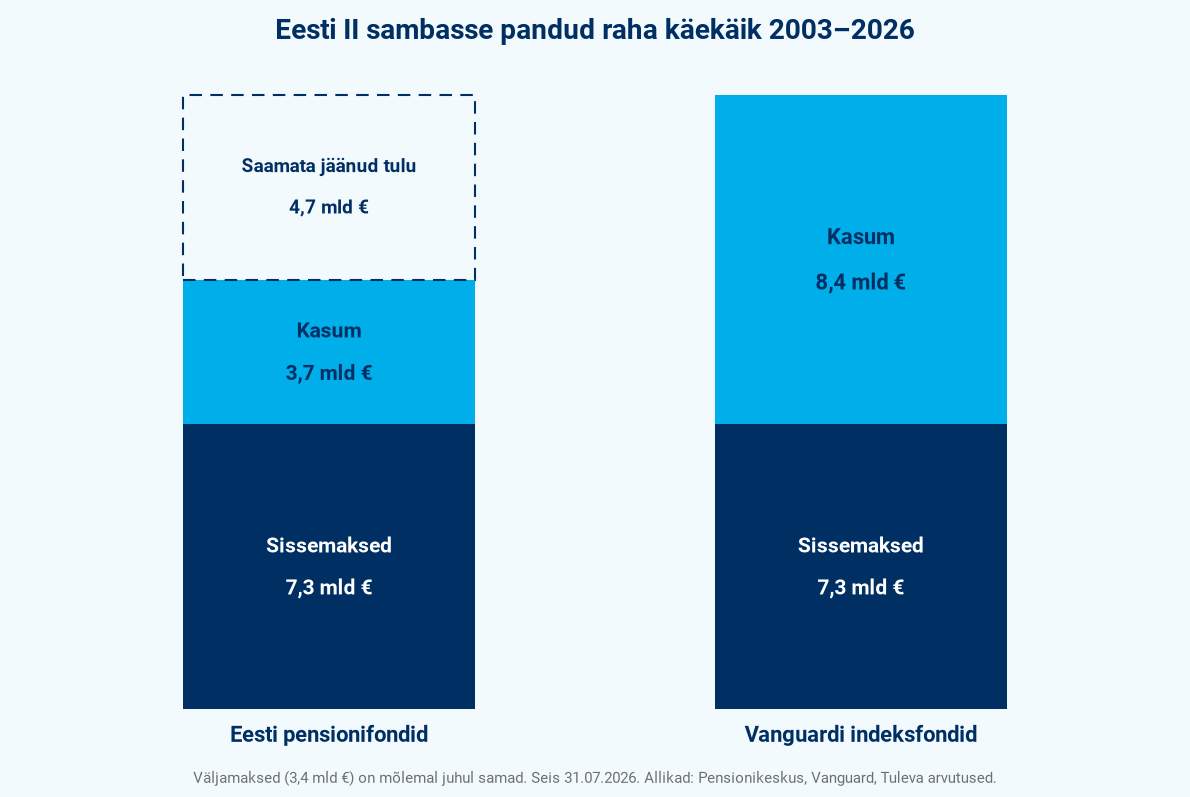

In [9]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.patches import Rectangle

NAVY, BRIGHT, TEXT, TEXT2, BG = '#002F63', '#00AEEA', '#293036', '#6B7074', '#f3fafe'
for ttf in ['Roboto-Regular.ttf', 'Roboto-Bold.ttf']:
    pth = Path.home() / 'Library' / 'Fonts' / ttf
    if pth.exists():
        fm.fontManager.addfont(str(pth))
plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['Roboto', 'Helvetica Neue', 'Arial', 'DejaVu Sans'],
                     'figure.facecolor': BG, 'axes.facecolor': BG, 'savefig.facecolor': BG, 'svg.fonttype': 'none'})

S = base['sissemaksed'] / 1e9; K = base['kasum'] / 1e9; KV = base['vanguard_kasum'] / 1e9; D = base['vahe'] / 1e9
def eur(x): return f'{x:.1f}'.replace('.', ',') + ' mld €'

fig, ax = plt.subplots(figsize=(12, 8))
x = [0, 1]; wdt = 0.55
ax.bar(x, [S, S], wdt, color=NAVY)
ax.bar(x, [K, KV], wdt, bottom=[S, S], color=BRIGHT)
ax.add_patch(Rectangle((x[0] - wdt / 2, S + K), wdt, D, fill=False, edgecolor=NAVY, linewidth=1.5, linestyle=(0, (6, 4))))
for xi, (lab, val, y0, col) in enumerate([('Sissemaksed', S, S / 2, 'white'), ('Kasum', K, S + K / 2, NAVY)]):
    pass
ax.text(x[0], S / 2, f'Sissemaksed\n{eur(S)}', ha='center', va='center', color='white', fontsize=15, fontweight='bold', linespacing=1.6)
ax.text(x[1], S / 2, f'Sissemaksed\n{eur(S)}', ha='center', va='center', color='white', fontsize=15, fontweight='bold', linespacing=1.6)
ax.text(x[0], S + K / 2, f'Kasum\n{eur(K)}', ha='center', va='center', color=NAVY, fontsize=15, fontweight='bold', linespacing=1.6)
ax.text(x[1], S + KV / 2, f'Kasum\n{eur(KV)}', ha='center', va='center', color=NAVY, fontsize=16, fontweight='bold', linespacing=1.6)
ax.text(x[0], S + K + D / 2, f'Saamata jäänud tulu\n{eur(D)}', ha='center', va='center', color=NAVY, fontsize=14, fontweight='bold', linespacing=1.6)
ax.set_xticks(x); ax.set_xticklabels(['Eesti pensionifondid', 'Vanguardi indeksfondid'], fontsize=16, fontweight='bold', color=NAVY)
ax.set_xlim(-0.6, 1.6); ax.set_ylim(0, S + KV + 0.8)
for sp in ax.spines.values(): sp.set_visible(False)
ax.set_yticks([]); ax.tick_params(bottom=False)
ax.set_title('Eesti II sambasse pandud raha käekäik 2003–2026', fontsize=20, fontweight='bold', color=NAVY, pad=18)
fig.text(0.5, 0.015, 'Väljamaksed (%s) on mõlemal juhul samad. Seis 31.07.2026. Allikad: Pensionikeskus, Vanguard, Tuleva arvutused.' % eur(base['valjamaksed'] / 1e9),
         ha='center', fontsize=11, color=TEXT2)
fig.tight_layout(rect=(0, 0.04, 1, 1))
for ext in ('png', 'svg'):
    fig.savefig(CHARTS / f'chart-a-ii-samba-raha-kaekaik-2003-2026.{ext}', dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()

## Eeldused ja piirangud

- Väljamaksed on mõlemas variandis samad eurodes. Päriselt oleksid 2021. aastal lahkujad Vanguardi variandis võtnud välja rohkem, sest nende kontod olnuks suuremad; proportsionaalsete väljamaksete variant (kogujõukuse vahe 3,9 mld) katab selle.
- Tuletatud väljamaksed on jääk (maht − eelmine maht × EPI tootlus − sissemaksed) ja kuutasemel mürased: fondide mahu ja EPI-II kuupäevad ei lange alati täpselt kokku ja EPI on kaalutud keskmine, mitte iga fondi tegelik tulu. Seetõttu tuleb W ligi kolmandikul kuudest negatiivne (kokku umbes −0,7 mld). Aastasummad ja 2021. aasta reformi voor klapivad avaldatud numbritega, aga `yearly_table.csv` üksikuid ridu ei tasu kuutäpsusega tõlgendada.
- Alternatiivportfelli aktsiate osakaal 75% on alates 2019. aastast konservatiivne valik: seadus lubab 100% ja Eesti fondide keskmine aktsiaosakaal on kasvanud. 100% variant on toodud eraldi.
- Vanguardi fondide 2003–2008 tootlused pärinevad Yahoo Finance'ist (fondide faktilehed katavad 10 aastat); nende aastate kaal tulemuses on väike.
- Sissemaksed ei sisalda pensioni investeerimiskontole (PIK) läinud raha (~48 M€ alates 2021), sest see ei ole fondides.